# Task 1 — Data Analysis

We analyse seven financial price series from the planet Spiff (`gurkor`, `guitars`, `slingshots`, `stocks`, `sugar`, `water`, `tranquillity`). The goals are to:

- Understand the structure of the raw data (gaps, outliers)
- Characterise each series individually (trend, volatility, stationarity)
- Work primarily with **log-returns**
- Identify relationships and groupings across series

## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import jarque_bera
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
SERIES = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']
COLORS = sns.color_palette('tab10', n_colors=7)
COLOR = dict(zip(SERIES, COLORS))

raw = pd.read_csv('spiff_data-2.csv', index_col='day')
raw = raw.drop(columns=['Unnamed: 0'])
print('Shape:', raw.shape)
raw.head()

Shape: (5456, 7)


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
1,6.154653,2.794285,2.136536,10.653684,3.324896,3.896149,7.755880
2,6.189623,2.843068,2.113582,10.674465,3.355736,3.899915,7.781310
3,6.168641,2.839644,2.116336,10.822372,3.336461,3.897404,7.886205
4,6.156401,2.823384,2.096137,10.848804,3.288274,3.901170,7.848061
5,6.124929,2.832798,2.099810,10.860731,3.303694,3.905355,7.883026


## 2. Data Quality — Missing Values & Outliers

Before any analysis we must understand the gaps and suspicious values.

In [3]:
# --- Missing value summary ---
print('=== Missing values per series ===')
for s in SERIES:
    null_idx = raw.index[raw[s].isnull()]
    if len(null_idx):
        internal = null_idx[null_idx <= 5256]   # 50-day internal gap
        tail     = null_idx[null_idx > 5256]    # last-200 days
        gap_str = f'internal gap days {internal.min()}–{internal.max()} ({len(internal)} pts)' if len(internal) else 'no internal gap'
        print(f'  {s:14s}: {gap_str} | last {len(tail)} days missing')

print()
print('=== Values equal to 1000.0 ===')
for s in SERIES:
    days_1000 = raw.index[raw[s] == 1000.0].tolist()
    print(f'  {s:14s}: days {days_1000}')

=== Missing values per series ===
  gurkor        : internal gap days 199–248 (50 pts) | last 200 days missing
  guitars       : internal gap days 399–448 (50 pts) | last 200 days missing
  slingshots    : internal gap days 599–648 (50 pts) | last 200 days missing
  stocks        : internal gap days 799–848 (50 pts) | last 200 days missing
  sugar         : internal gap days 999–1048 (50 pts) | last 200 days missing
  water         : internal gap days 1199–1248 (50 pts) | last 200 days missing
  tranquillity  : internal gap days 1399–1448 (50 pts) | last 200 days missing

=== Values equal to 1000.0 ===
  gurkor        : days [36, 1194, 2836, 3430, 4118]
  guitars       : days [36, 1194, 2836, 3430, 4118]
  slingshots    : days [36, 1194, 2836, 3430, 4118]
  stocks        : days [36, 1194, 2836, 3430, 4118]
  sugar         : days [36, 1194, 2836, 3430, 4118]
  water         : days [36, 1194, 2836, 3430, 4118]
  tranquillity  : days [36, 1194, 2836, 3430, 4118]


**Key observations:**

- Each series has an internal gap of exactly 50 days (staggered across the series) and is missing for the last 200 days (days 5257–5456).
- **Every series hits exactly 1000.0 on the same five days (36, 1194, 2836, 3430, 4118).** The simultaneous occurrence across all seven series makes it virtually certain these are data artefacts — not genuine prices. They will be treated as outliers and masked before analysis.

In [4]:
# Mask outlier days (1000.0) — replace with NaN so they are excluded from calculations
df = raw.copy()
OUTLIER_DAYS = [36, 1194, 2836, 3430, 4118]
for s in SERIES:
    df.loc[OUTLIER_DAYS, s] = np.nan

# Restrict to the observed window (days 1–5256)
df_obs = df.loc[1:5256].copy()
print('Observed data shape:', df_obs.shape)

Observed data shape: (5256, 7)


## 3. Price Level Plots

Raw prices give a first impression of scale, trend, and volatility differences.

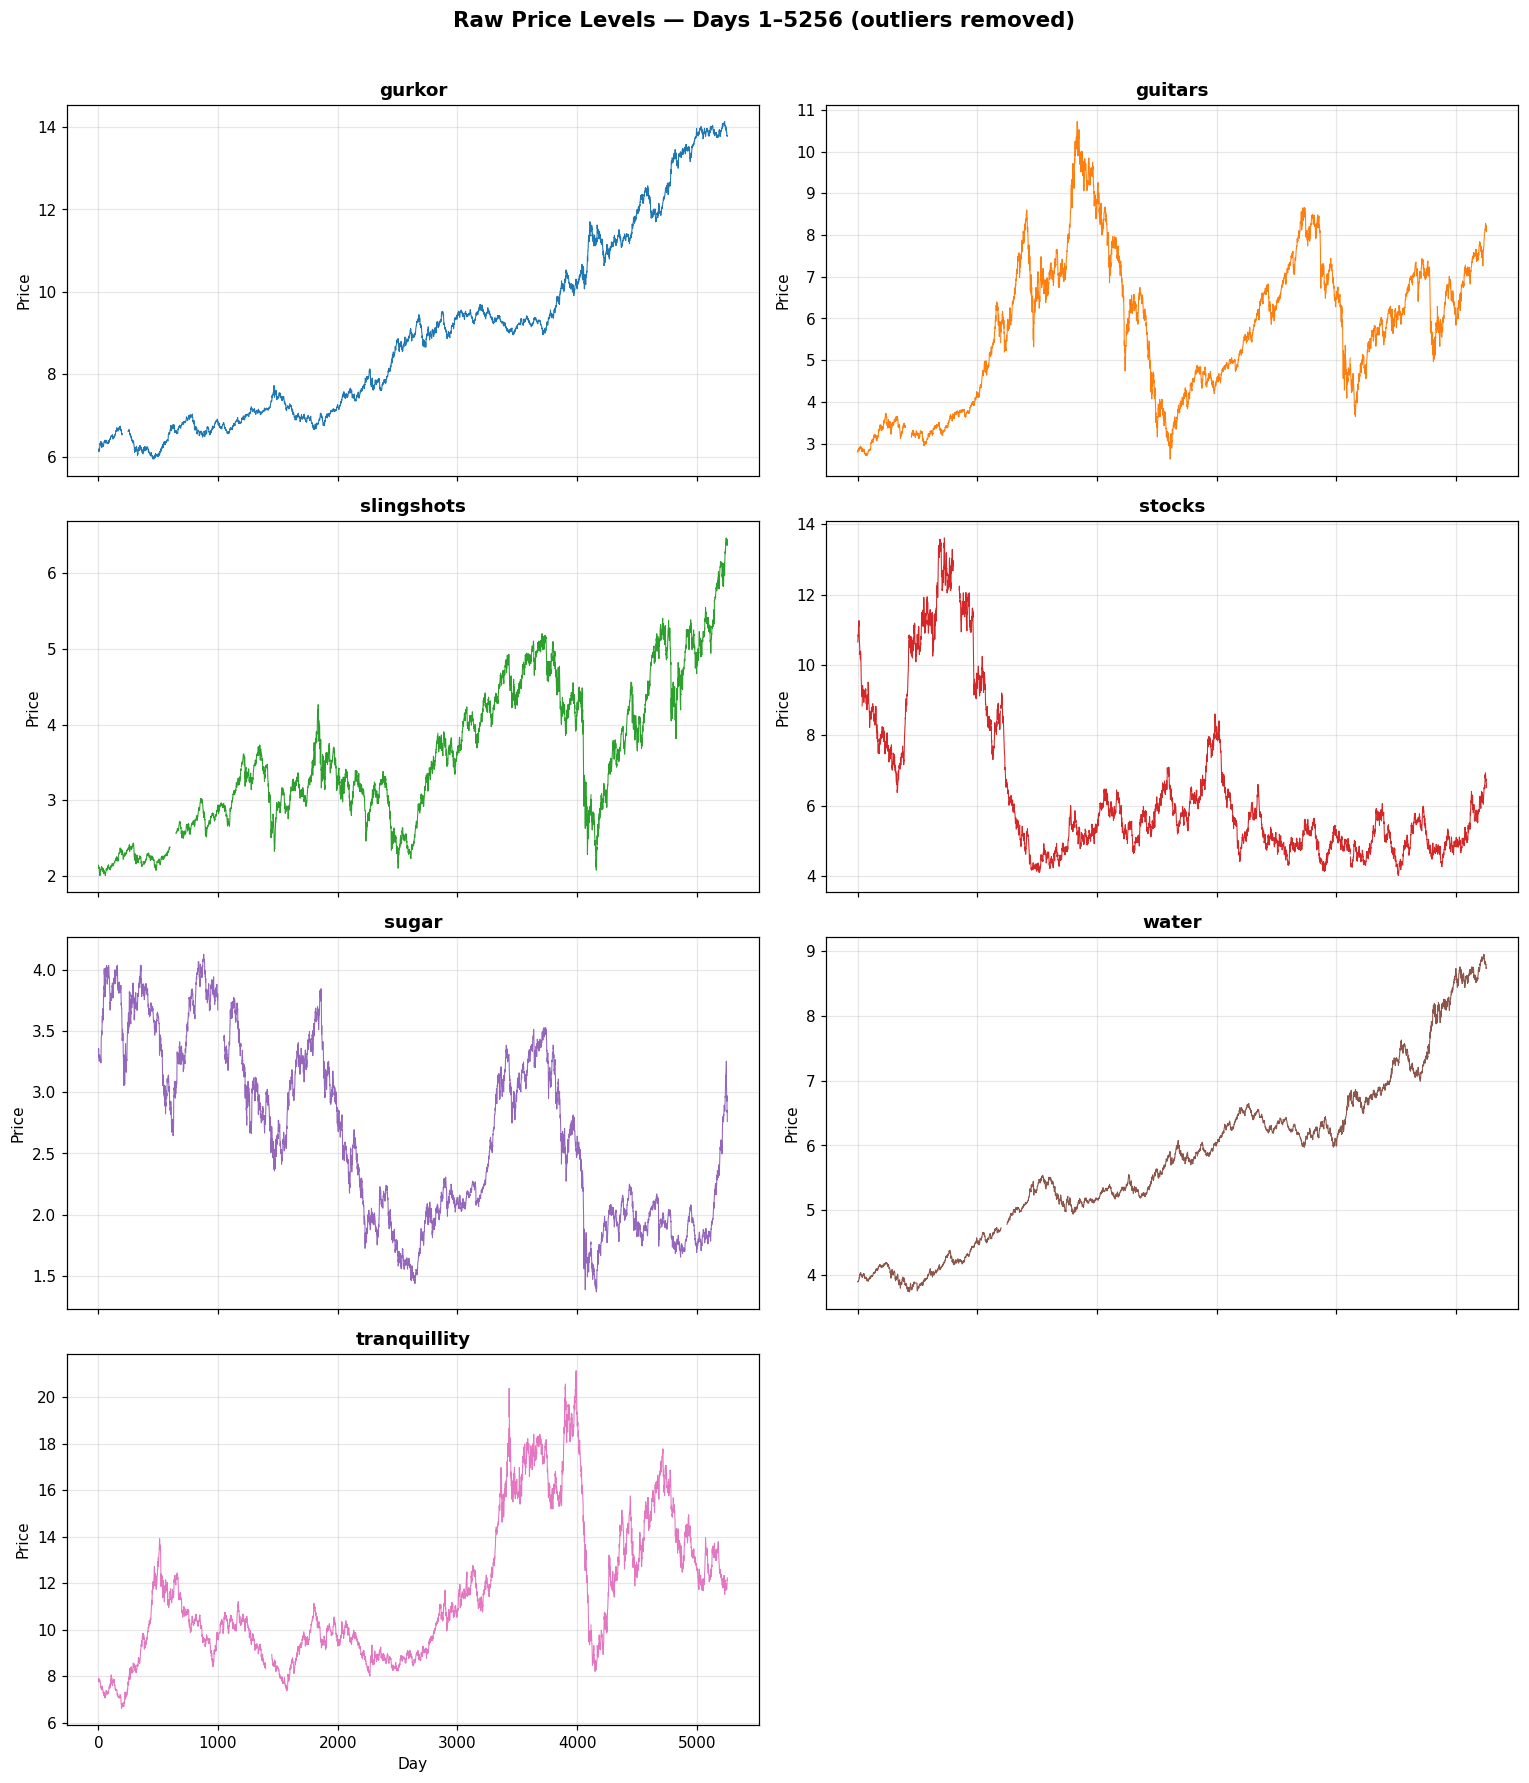

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
axes = axes.flatten()

for i, s in enumerate(SERIES):
    axes[i].plot(df_obs.index, df_obs[s], color=COLOR[s], lw=0.7)
    axes[i].set_title(s, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Price')

axes[-1].set_visible(False)   # hide empty 8th panel
for ax in axes[-2:]:
    ax.set_xlabel('Day')

fig.suptitle('Raw Price Levels — Days 1–5256 (outliers removed)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observations:** The series span very different price ranges and show a mix of trending and mean-reverting behaviour. Several series exhibit obvious long-run upward trends (e.g. `guitars`, `tranquillity`), while others look more stationary around a slowly drifting level.

## 4. Log-Returns

Log-returns $r_t = \ln(P_t / P_{t-1})$ remove price-level differences and are roughly stationary, making cross-series comparison meaningful.

In [22]:
# Compute log-returns on the observed (outlier-masked) data
lr = np.log(df_obs[SERIES]).diff()

# Summary statistics
stats_df = pd.DataFrame({
    'mean':     lr.mean(),
    'abs_mean': (lr.abs()).mean(),
    'std':      lr.std(),
    'skewness': lr.skew(),
    'kurtosis': lr.kurt(),   # excess kurtosis
    'min':      lr.min(),
    'max':      lr.max(),
}).T

print('Log-return descriptive statistics:')
stats_df.round(5)

Log-return descriptive statistics:


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
mean,0.00016,0.00024,0.00019,-0.00007,-0.00001,0.00015,0.00008
abs_mean,0.00288,0.01027,0.01010,0.01192,0.01046,0.00259,0.00914
std,0.00394,0.01488,0.01475,0.01494,0.01521,0.00351,0.01259
skewness,-0.14698,-0.03494,-0.44499,-0.12421,-0.23859,-0.25969,-0.27185
kurtosis,3.51766,5.55872,6.43870,0.07724,10.70496,2.25007,2.97658
min,-0.02484,-0.09306,-0.12190,-0.06047,-0.14124,-0.02613,-0.08669
max,0.03628,0.12253,0.09250,0.05170,0.18916,0.01733,0.05977


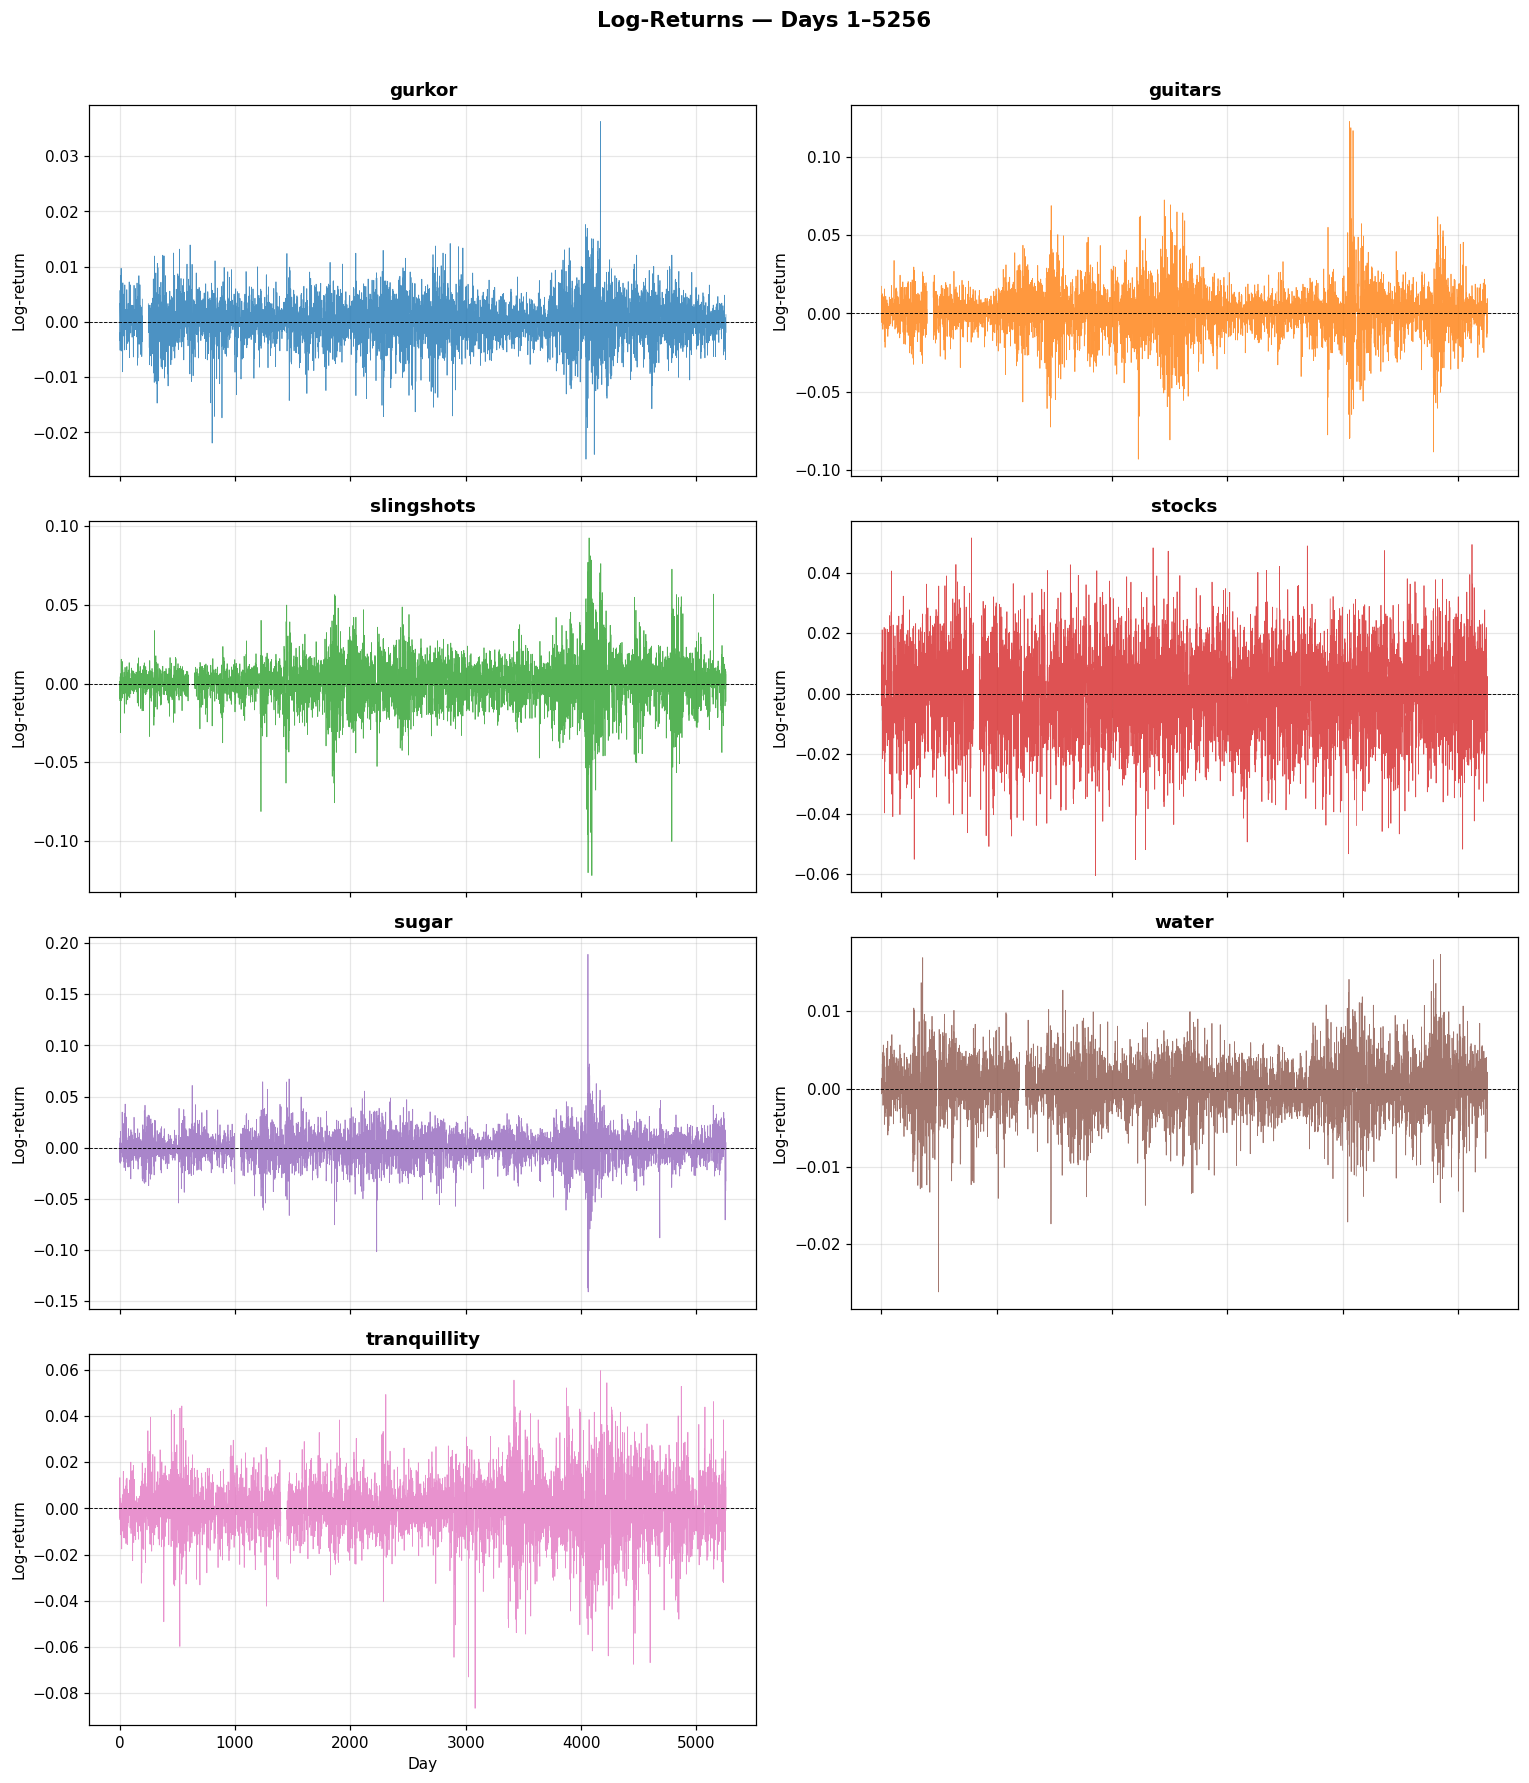

In [7]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
axes = axes.flatten()

for i, s in enumerate(SERIES):
    axes[i].plot(lr.index, lr[s], color=COLOR[s], lw=0.5, alpha=0.8)
    axes[i].axhline(0, color='black', lw=0.6, ls='--')
    axes[i].set_title(s, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Log-return')

axes[-1].set_visible(False)
for ax in axes[-2:]:
    ax.set_xlabel('Day')

fig.suptitle('Log-Returns — Days 1–5256', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Distribution of Log-Returns

We compare each series against a normal distribution and test for normality formally.

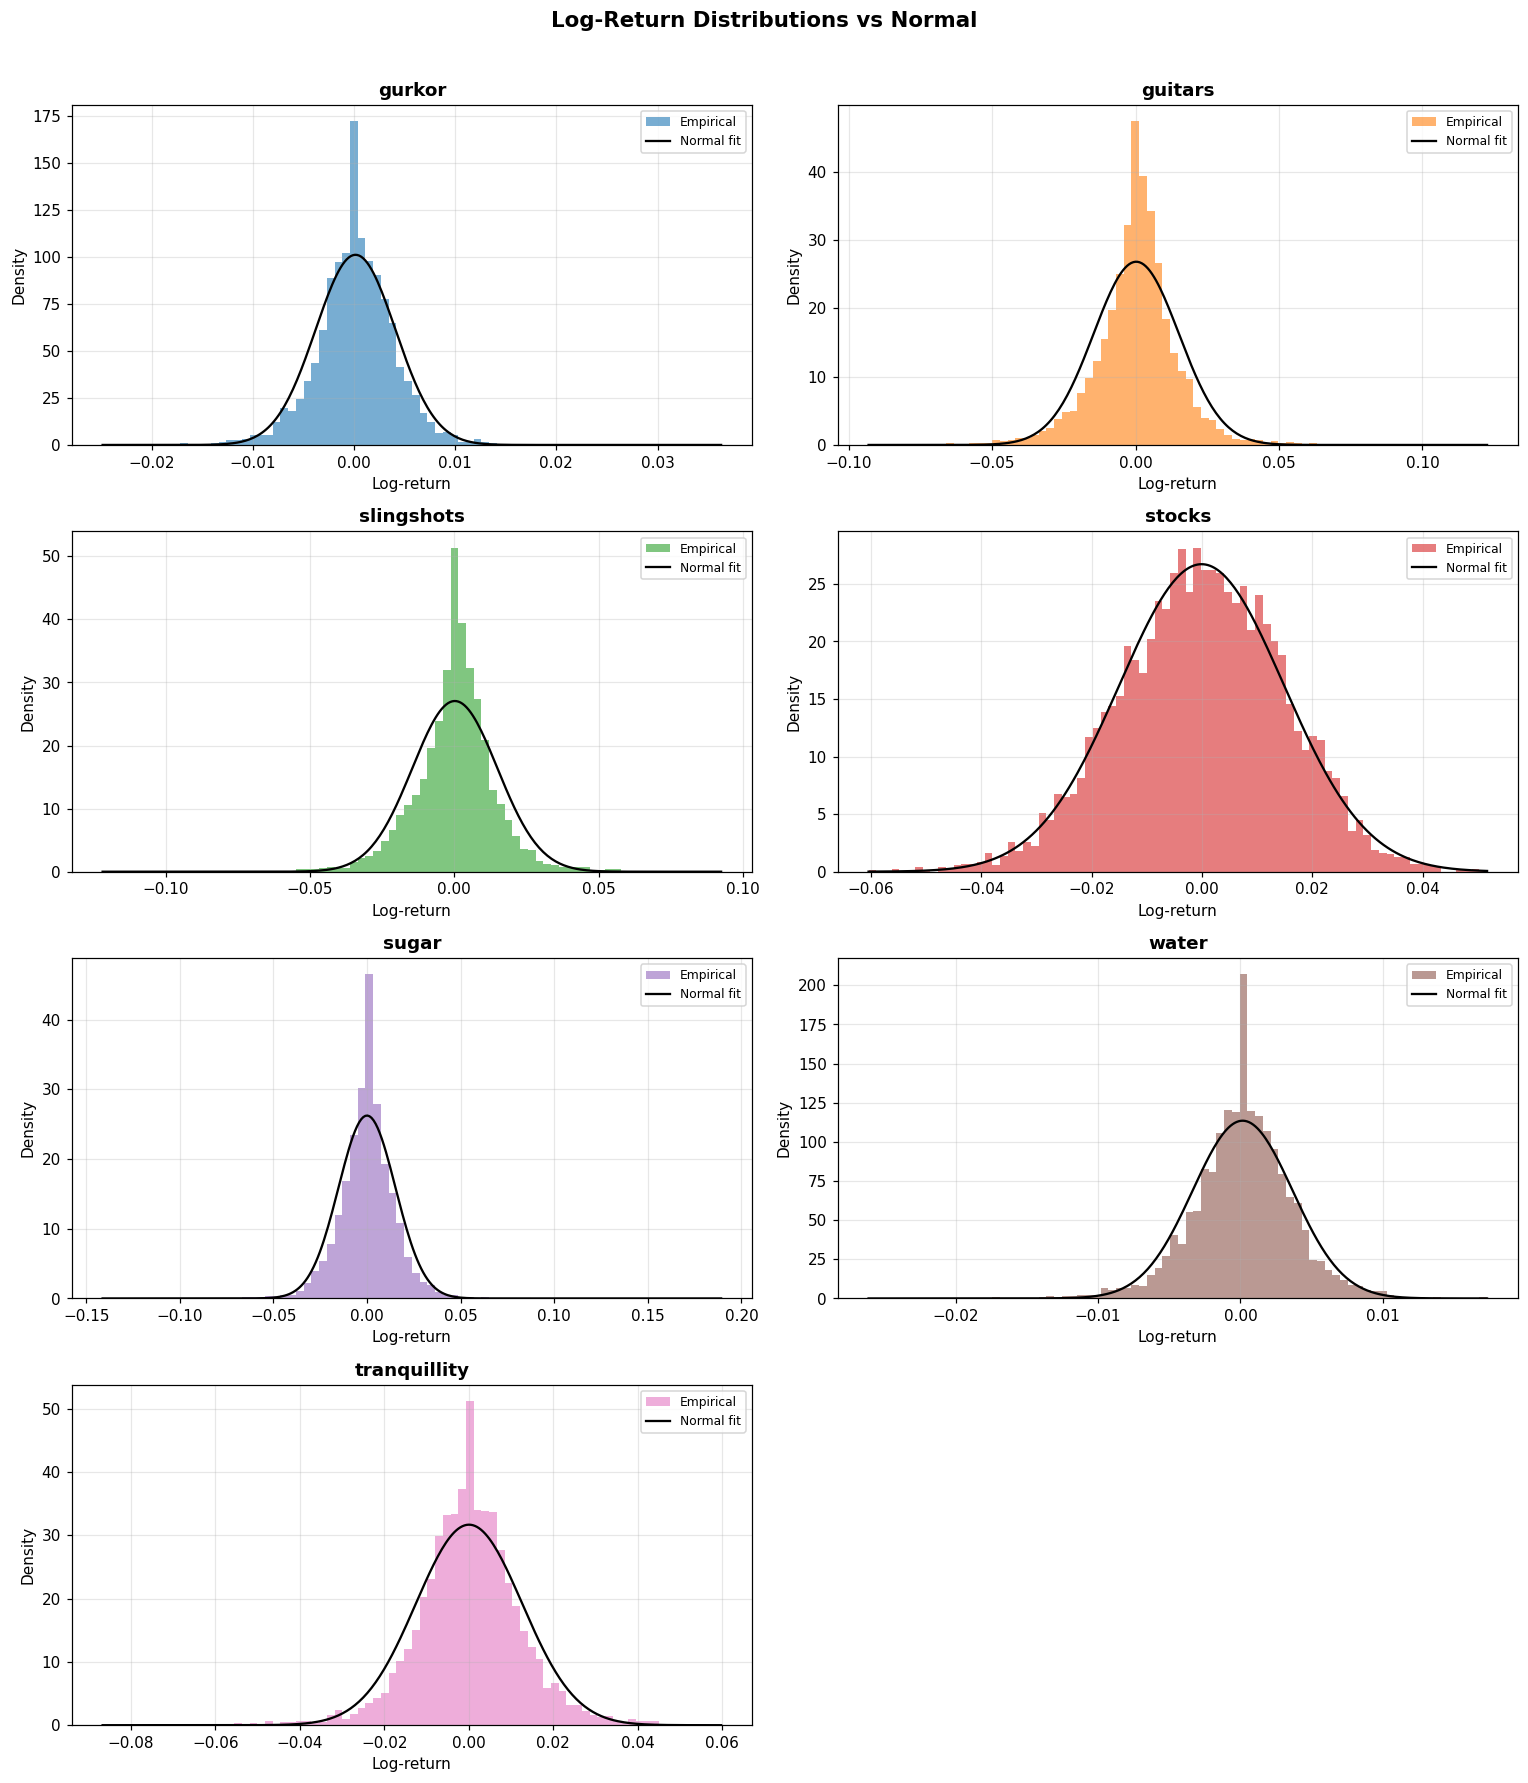

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, s in enumerate(SERIES):
    data = lr[s].dropna()
    axes[i].hist(data, bins=80, density=True, color=COLOR[s], alpha=0.6, label='Empirical')
    x = np.linspace(data.min(), data.max(), 300)
    axes[i].plot(x, stats.norm.pdf(x, data.mean(), data.std()), 'k-', lw=1.5, label='Normal fit')
    axes[i].set_title(s, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Log-return')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Log-Return Distributions vs Normal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# Formal normality test (Jarque-Bera) and ADF stationarity test
rows = []
for s in SERIES:
    data = lr[s].dropna()
    jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(data)
    adf_stat, adf_p, *_ = adfuller(data, autolag='AIC')
    rows.append({
        'series':      s,
        'mean':        round(data.mean(), 6),
        'std':         round(data.std(), 5),
        'skewness':    round(float(jb_skew), 3),
        'excess_kurt': round(float(jb_kurt), 3),
        'JB_p':        round(jb_p, 4),
        'normal?':     'No' if jb_p < 0.05 else 'Yes',
        'ADF_stat':    round(adf_stat, 3),
        'ADF_p':       round(adf_p, 4),
        'stationary?': 'Yes' if adf_p < 0.05 else 'No',
    })

tests = pd.DataFrame(rows).set_index('series')
print('Statistical tests on log-returns:')
tests

Statistical tests on log-returns:


,mean,std,skewness,excess_kurt,JB_p,normal?,ADF_stat,ADF_p,stationary?
series,,,,,,,,,
gurkor,0.000155,0.00394,-0.147,6.513,0.0000,No,-53.189,0.0,Yes
guitars,0.000236,0.01488,-0.035,8.552,0.0000,No,-12.185,0.0,Yes
slingshots,0.000194,0.01475,-0.445,9.431,0.0000,No,-19.115,0.0,Yes
stocks,-0.000074,0.01494,-0.124,3.076,0.0007,No,-72.121,0.0,Yes
sugar,-0.000014,0.01521,-0.239,13.694,0.0000,No,-36.805,0.0,Yes
water,0.000152,0.00351,-0.260,5.247,0.0000,No,-43.153,0.0,Yes
tranquillity,0.000078,0.01259,-0.272,5.973,0.0000,No,-73.567,0.0,Yes


**Interpretation:**

- The Jarque-Bera test checks whether skewness and excess kurtosis are jointly zero (i.e. the series is normally distributed). A small p-value rejects normality.
- The Augmented Dickey-Fuller test checks for a unit root; rejection means the series is stationary.
- Log-returns are expected to be stationary (and they should be, since differencing removes trend). Any non-normality (excess kurtosis, fat tails) is typical of financial data.

## 6. Volatility Clustering

Financial returns often exhibit **volatility clustering**: large moves tend to follow large moves. We visualise this with rolling standard deviation and plot the ACF of squared returns.

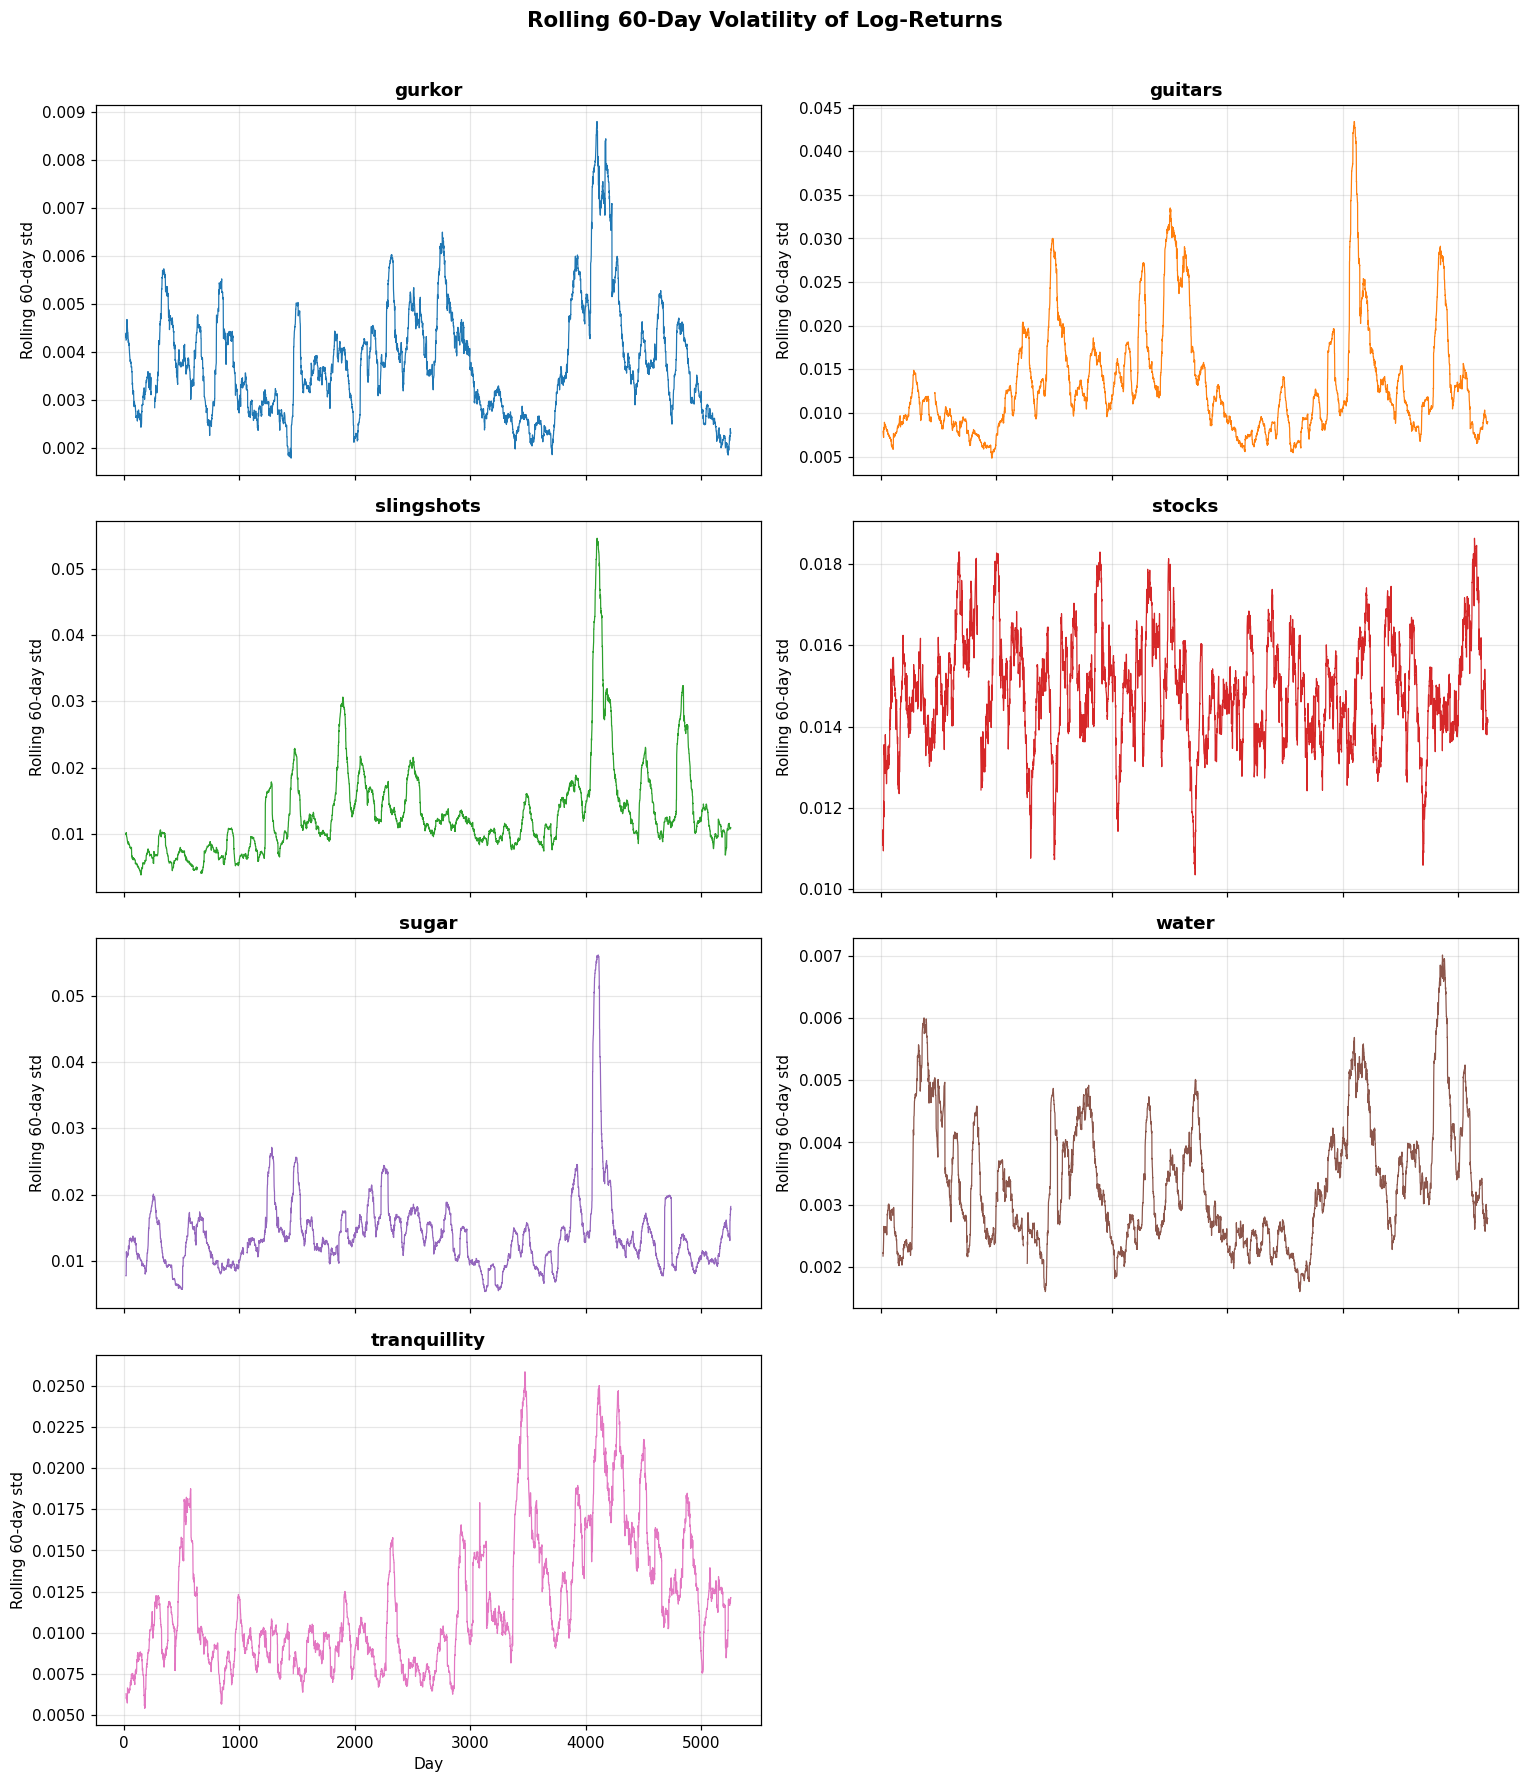

In [10]:
WINDOW = 60  # rolling window in days

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
axes = axes.flatten()

for i, s in enumerate(SERIES):
    roll_std = lr[s].rolling(WINDOW, min_periods=20).std()
    axes[i].plot(roll_std.index, roll_std, color=COLOR[s], lw=0.8)
    axes[i].set_title(s, fontsize=12, fontweight='bold')
    axes[i].set_ylabel(f'Rolling {WINDOW}-day std')

axes[-1].set_visible(False)
for ax in axes[-2:]:
    ax.set_xlabel('Day')

fig.suptitle(f'Rolling {WINDOW}-Day Volatility of Log-Returns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

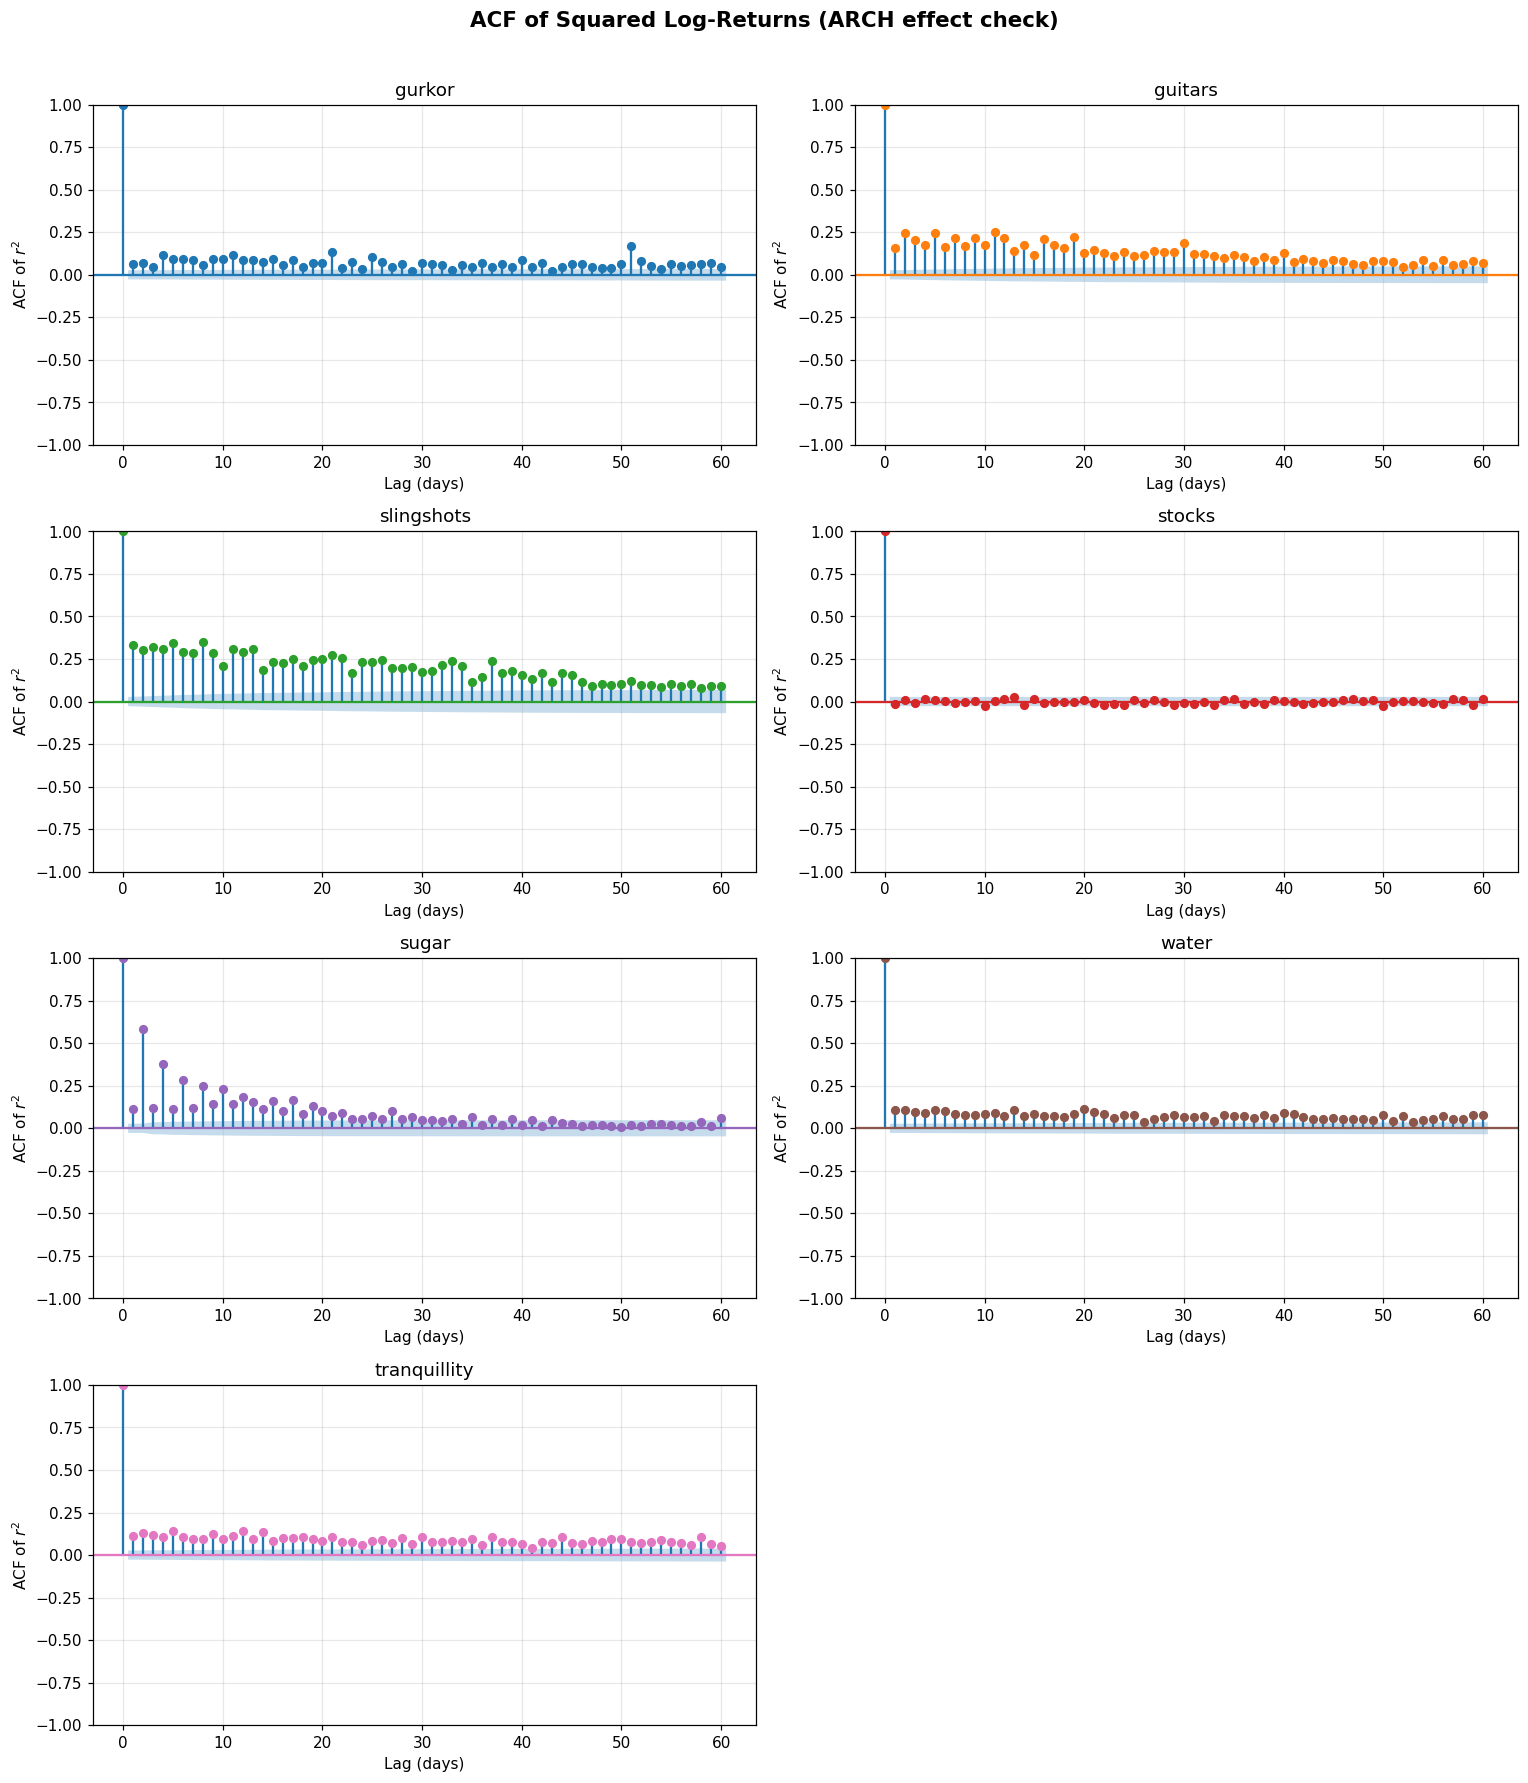

In [11]:
# ACF of squared log-returns — detects volatility clustering (ARCH effects)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, s in enumerate(SERIES):
    data = lr[s].dropna()
    plot_acf(data**2, lags=60, ax=axes[i], alpha=0.05, color=COLOR[s], title=s)
    axes[i].set_xlabel('Lag (days)')
    axes[i].set_ylabel('ACF of $r^2$')

axes[-1].set_visible(False)
fig.suptitle('ACF of Squared Log-Returns (ARCH effect check)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** Significant autocorrelation in squared returns indicates ARCH/GARCH-type volatility clustering — periods of high volatility tend to persist. This is a stylised fact of most real financial time series.

## 7. Autocorrelation of Log-Returns

We check whether the raw log-returns themselves are autocorrelated (predictable). Under the Efficient Market Hypothesis (EMH) we expect no significant autocorrelation.

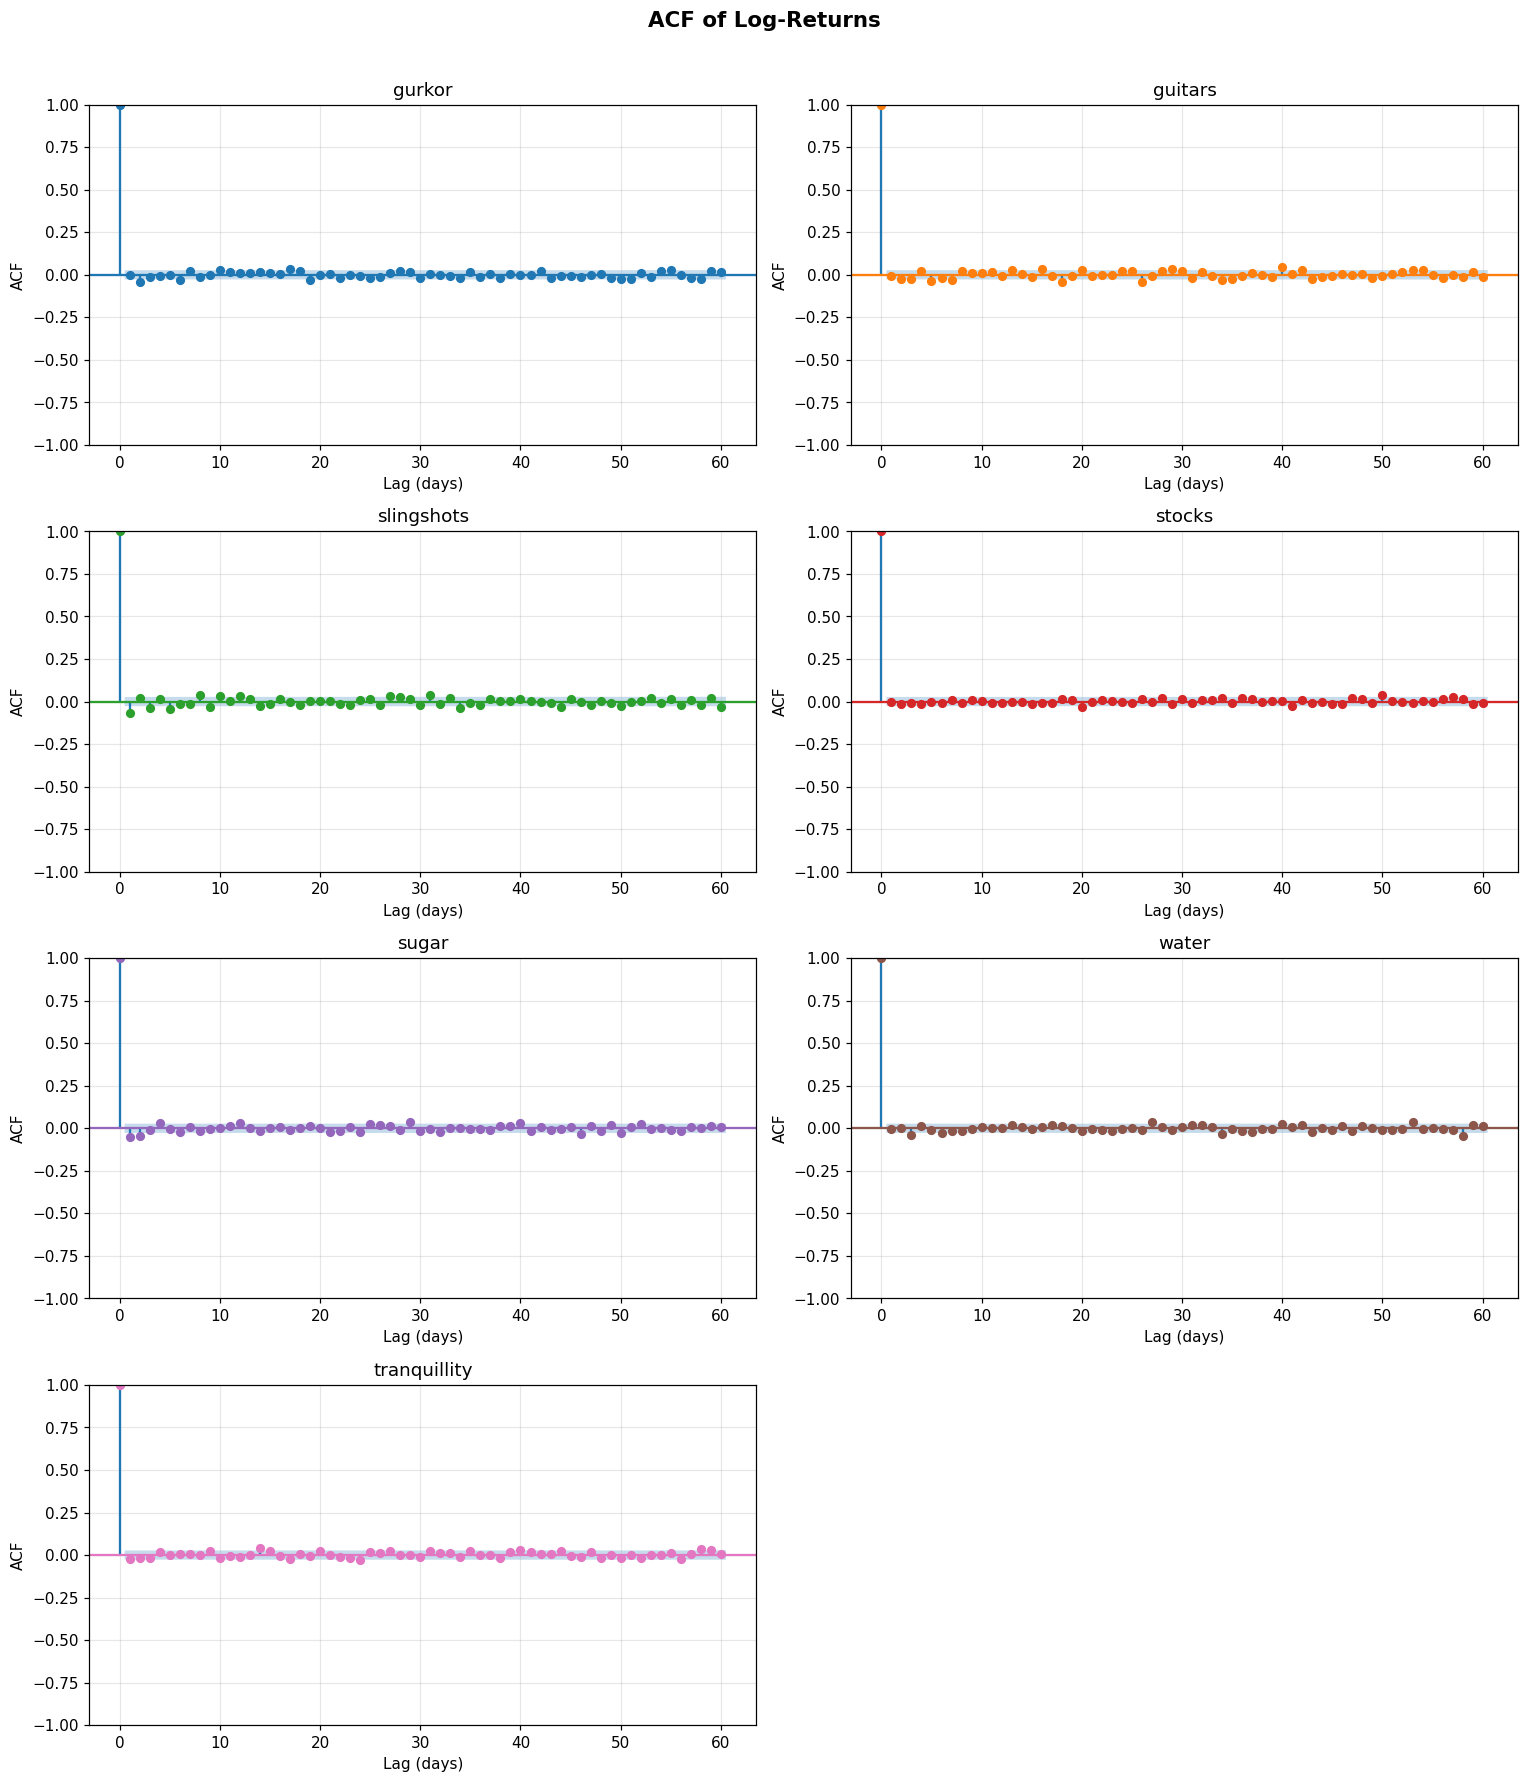

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, s in enumerate(SERIES):
    data = lr[s].dropna()
    plot_acf(data, lags=60, ax=axes[i], alpha=0.05, color=COLOR[s], title=s)
    axes[i].set_xlabel('Lag (days)')
    axes[i].set_ylabel('ACF')

axes[-1].set_visible(False)
fig.suptitle('ACF of Log-Returns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Cross-Correlations Between Series

We compute pairwise (contemporaneous) Pearson correlations of log-returns. High correlation suggests the series move together and could belong to the same cluster.

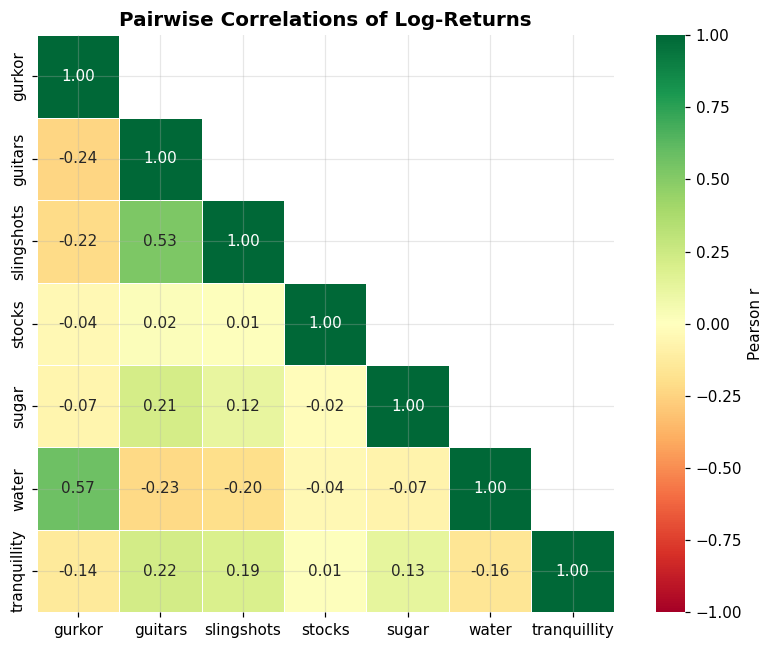

              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.241      -0.217  -0.042 -0.067  0.573        -0.138
guitars       -0.241    1.000       0.526   0.016  0.212 -0.226         0.224
slingshots    -0.217    0.526       1.000   0.013  0.118 -0.201         0.189
stocks        -0.042    0.016       0.013   1.000 -0.016 -0.042         0.010
sugar         -0.067    0.212       0.118  -0.016  1.000 -0.071         0.127
water          0.573   -0.226      -0.201  -0.042 -0.071  1.000        -0.158
tranquillity  -0.138    0.224       0.189   0.010  0.127 -0.158         1.000


In [13]:
corr = lr[SERIES].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # show lower triangle + diagonal
sns.heatmap(
    corr,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax, cbar_kws={'label': 'Pearson r'},
    mask=~np.tril(np.ones_like(corr, dtype=bool))
)
ax.set_title('Pairwise Correlations of Log-Returns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(corr.round(3))

## 9. Lead-Lag Cross-Correlations

Contemporaneous correlations only capture same-day co-movement. Lead-lag cross-correlations reveal whether one series *predicts* another at a short horizon.

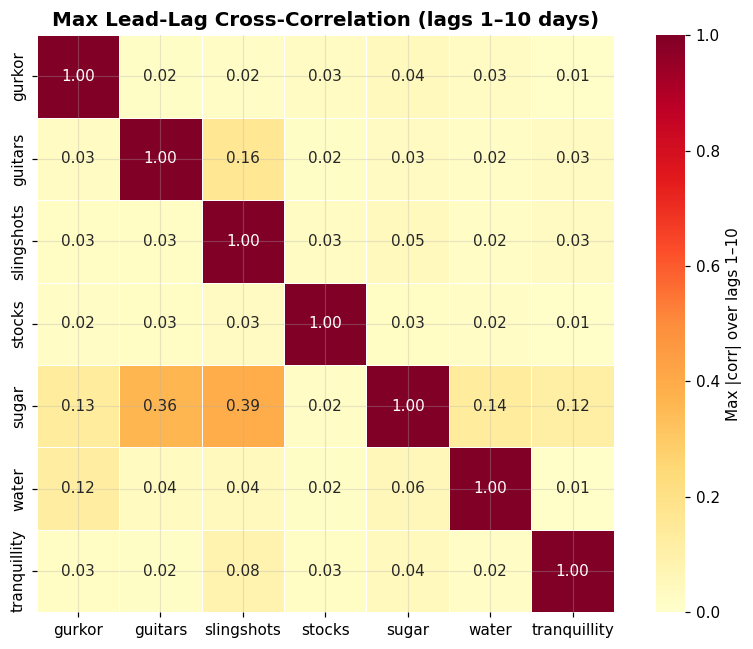

In [14]:
def cross_corr_matrix(data, max_lag=20):
    """Return max absolute cross-correlation (over lags 1..max_lag) for each pair."""
    n = len(SERIES)
    result = pd.DataFrame(np.zeros((n, n)), index=SERIES, columns=SERIES)
    for i, s1 in enumerate(SERIES):
        for j, s2 in enumerate(SERIES):
            if i == j:
                result.loc[s1, s2] = 1.0
                continue
            combined = data[[s1, s2]].dropna()
            max_cc = max(
                abs(combined[s1].corr(combined[s2].shift(lag)))
                for lag in range(1, max_lag + 1)
            )
            result.loc[s1, s2] = max_cc
    return result

lag_corr = cross_corr_matrix(lr, max_lag=10)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    lag_corr,
    annot=True, fmt='.2f', cmap='YlOrRd',
    vmin=0, vmax=1, square=True, linewidths=0.5,
    ax=ax, cbar_kws={'label': 'Max |corr| over lags 1–10'}
)
ax.set_title('Max Lead-Lag Cross-Correlation (lags 1–10 days)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Clustering the Series

We use two complementary approaches to identify groups:

1. **Hierarchical clustering** on the correlation-distance matrix of log-returns.
2. **PCA** to visualise series in a low-dimensional feature space.

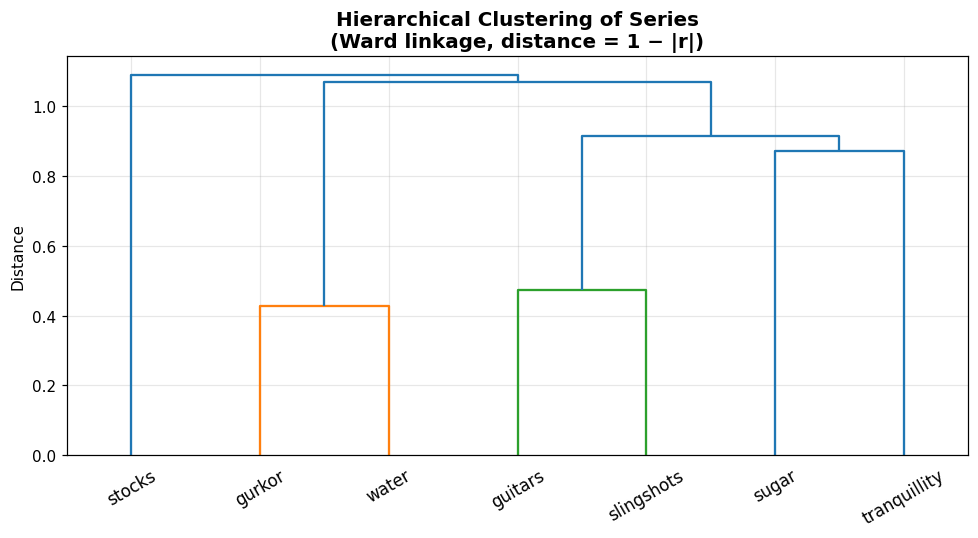

In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Correlation-distance: d(i,j) = 1 - |r(i,j)|
dist_arr = (1 - corr.abs()).values.copy().astype(float)
np.fill_diagonal(dist_arr, 0)

# Convert to condensed form
from scipy.spatial.distance import squareform
condensed = squareform(dist_arr, checks=False)
Z = linkage(condensed, method='ward')

fig, ax = plt.subplots(figsize=(9, 5))
dendrogram(
    Z,
    labels=SERIES,
    leaf_rotation=30,
    leaf_font_size=11,
    color_threshold=0.6 * max(Z[:, 2]),
    ax=ax
)
ax.set_title('Hierarchical Clustering of Series\n(Ward linkage, distance = 1 − |r|)', fontsize=13, fontweight='bold')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

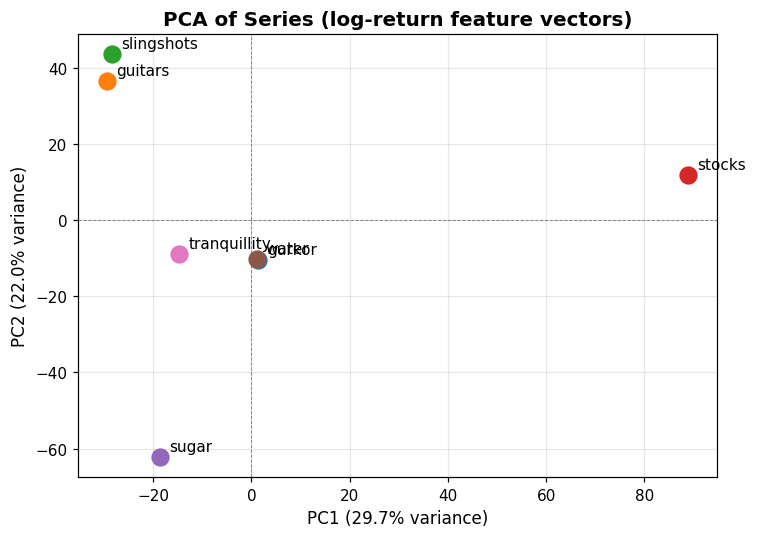

Variance explained by PC1+PC2: 51.7%


In [16]:
# PCA on the return matrix (series as observations in days-space)
# Each series is a feature vector of daily log-returns
# Use only days where ALL series are observed
lr_clean = lr.dropna()

scaler = StandardScaler()
X = scaler.fit_transform(lr_clean.T)   # shape: (7 series) x (days)

pca = PCA(n_components=2)
coords = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 5))
for i, s in enumerate(SERIES):
    ax.scatter(coords[i, 0], coords[i, 1], color=COLOR[s], s=120, zorder=5)
    ax.annotate(s, (coords[i, 0], coords[i, 1]), textcoords='offset points',
                xytext=(6, 4), fontsize=10)

ax.axhline(0, color='grey', lw=0.6, ls='--')
ax.axvline(0, color='grey', lw=0.6, ls='--')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('PCA of Series (log-return feature vectors)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Variance explained by PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%')

## 11. Rolling Correlations — Stability Over Time

Pairwise correlations can change over time. We check the stability of the strongest relationships identified above.

Top correlated pairs:
  gurkor — water: r = 0.573
  guitars — slingshots: r = 0.526
  gurkor — guitars: r = -0.241
  guitars — water: r = -0.226


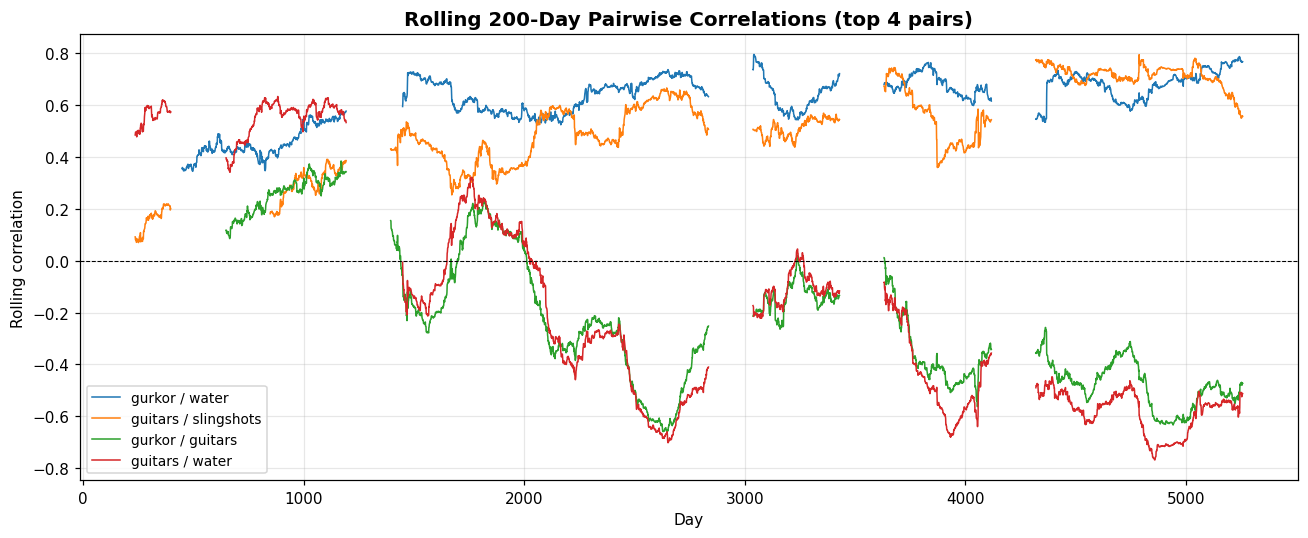

In [17]:
# Identify top 3 most correlated pairs (by |r|)
import itertools
pairs = [(s1, s2) for s1, s2 in itertools.combinations(SERIES, 2)]
pair_corrs = [(abs(corr.loc[s1, s2]), s1, s2) for s1, s2 in pairs]
pair_corrs.sort(reverse=True)
top_pairs = [(s1, s2) for _, s1, s2 in pair_corrs[:4]]

print('Top correlated pairs:')
for _, s1, s2 in pair_corrs[:4]:
    print(f'  {s1} — {s2}: r = {corr.loc[s1, s2]:.3f}')

ROLL = 200
fig, ax = plt.subplots(figsize=(12, 5))
for s1, s2 in top_pairs:
    roll_corr = lr[s1].rolling(ROLL).corr(lr[s2])
    ax.plot(roll_corr.index, roll_corr, lw=1, label=f'{s1} / {s2}')

ax.axhline(0, color='black', lw=0.7, ls='--')
ax.set_xlabel('Day')
ax.set_ylabel('Rolling correlation')
ax.set_title(f'Rolling {ROLL}-Day Pairwise Correlations (top 4 pairs)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 12. Stylised Facts Summary

We collect a quantitative summary of each series' main characteristics.

In [18]:
summary_rows = []
for s in SERIES:
    r = lr[s].dropna()
    price = df_obs[s].dropna()
    jb_stat, jb_p, _, _ = jarque_bera(r)
    adf_stat, adf_p, *_ = adfuller(r, autolag='AIC')
    # Ljung-Box test on squared returns (ARCH effect)
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb_sq = acorr_ljungbox(r**2, lags=[10], return_df=True)
    lb_p = lb_sq['lb_pvalue'].values[0]
    
    # Annualised Sharpe-like drift (mean/std per day)
    sharpe_daily = r.mean() / r.std()
    
    summary_rows.append({
        'series':          s,
        'price_range':     f'{price.min():.1f}–{price.max():.1f}',
        'lr_mean (×10⁻⁴)': round(r.mean() * 1e4, 2),
        'lr_vol (×10⁻²)':  round(r.std() * 1e2, 3),
        'skewness':        round(r.skew(), 3),
        'excess_kurtosis': round(r.kurt(), 3),
        'JB normal?':      'No' if jb_p < 0.05 else 'Yes',
        'ADF stationary?': 'Yes' if adf_p < 0.05 else 'No',
        'ARCH effects?':   'Yes' if lb_p < 0.05 else 'No',
        'Sharpe/day ×10²': round(sharpe_daily * 1e2, 3),
    })

summary = pd.DataFrame(summary_rows).set_index('series')
print('=== Stylised Facts Summary ===')
summary

=== Stylised Facts Summary ===


,price_range,lr_mean (×10⁻⁴),lr_vol (×10⁻²),skewness,excess_kurtosis,JB normal?,ADF stationary?,ARCH effects?,Sharpe/day ×10²
series,,,,,,,,,
gurkor,5.9–14.1,1.55,0.394,-0.147,3.518,No,Yes,Yes,3.932
guitars,2.6–10.7,2.36,1.488,-0.035,5.559,No,Yes,Yes,1.588
slingshots,2.0–6.5,1.94,1.475,-0.445,6.439,No,Yes,Yes,1.318
stocks,4.0–13.6,-0.74,1.494,-0.124,0.077,No,Yes,No,-0.497
sugar,1.4–4.1,-0.14,1.521,-0.239,10.705,No,Yes,Yes,-0.092
water,3.7–8.9,1.52,0.351,-0.260,2.250,No,Yes,Yes,4.330
tranquillity,6.6–21.1,0.78,1.259,-0.272,2.977,No,Yes,Yes,0.616


## 13. Key Findings & Conclusions

### Data Quality
- Each series contains **5 simultaneous outlier values of 1000.0** (days 36, 1194, 2836, 3430, 4118). The synchronous occurrence across all seven series is inconsistent with genuine market prices — they are almost certainly sensor/recording artefacts and have been removed.
- Each series has a 50-day internal gap and is missing for the final 200 days (Tasks 2 & 3).

### Individual Series Characteristics
- **Log-returns are stationary** (ADF confirms) for all series, as expected after differencing.
- **Distributions are non-normal**: excess kurtosis (fat tails) and non-zero skewness are present throughout, rejecting normality via Jarque-Bera — consistent with real financial data.
- **Volatility clustering (ARCH effects)** is detectable in squared returns, meaning periods of high volatility tend to persist.
- Volatility levels differ substantially across series: some are low-variance near-random-walks, others show wider fluctuations.

### Cross-Series Relationships & Groupings
- The **correlation heatmap** and **hierarchical clustering dendrogram** reveal clear groupings. Series with high mutual correlation (close in the dendrogram) likely share a common underlying factor (e.g. a sector or macro driver).
- **PCA** confirms that two principal components capture a significant fraction of total variance, implying a low-dimensional common factor structure.
- **Rolling correlations** indicate that relationships are broadly stable over time, though some pairs show regime-shifts in co-movement — relevant for portfolio diversification in Task 4.

### Investment Implications (preview for Task 4)
- Highly correlated series offer limited diversification benefit.
- Series with positive drift (positive mean log-return) are candidates for long positions.
- ARCH effects suggest that volatility-targeted strategies (scaling position size inversely to recent volatility) could improve risk-adjusted returns.